#Vasu Dornala - The EDA Checklist Subjective

In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 200

data = {
    "order_id": range(1001, 1001 + n),
    "city": np.random.choice(["Mumbai", "Delhi", "Bangalore", "Chennai"], size=n),
    "category": np.random.choice(["Electronics", "Clothing", "Groceries", "Furniture"], size=n),
    "order_value": np.random.randint(200, 5000, size=n).astype(float),
    "delivery_days": np.random.randint(1, 15, size=n).astype(float),
    "rating": np.random.choice([1, 2, 3, 4, 5, None], size=n)
}

missing_indices_order = np.random.choice(n, size=15, replace=False)
missing_indices_delivery = np.random.choice(n, size=10, replace=False)
data["order_value"][missing_indices_order] = np.nan
data["delivery_days"][missing_indices_delivery] = np.nan

data["order_value"][5] = 95000
data["order_value"][88] = 87000

df = pd.DataFrame(data)
print(df.shape)
df.head()

(200, 6)


,order_id,city,category,order_value,delivery_days,rating
0,1001,Bangalore,Groceries,4191.0,11.0,4
1,1002,Chennai,Furniture,4923.0,12.0,1
2,1003,Mumbai,Groceries,4882.0,13.0,2
3,1004,Bangalore,Electronics,1848.0,13.0,1
4,1005,Bangalore,Furniture,1645.0,12.0,1


# Task 1 — Inspect & Handle Missing Values

In [5]:
# Task 1 — Inspect & Handle Missing Values

# 1. Print the shape of the DataFrame (number of rows and columns)
print("1. DataFrame Shape:", df.shape)

# 2. Display the data types of all columns
print("\n2. Data Types:\n", df.dtypes)

# 3. Count the number of missing values in each column
missing_count = df.isnull().sum()
print("\n3. Missing Values:\n", missing_count)

# 4. Calculate the percentage of missing values for each column, rounded to 2 decimal places
missing_percentage = (missing_count / len(df)) * 100
print("\n4. Missing Percentage:\n", missing_percentage.round(2))


1. DataFrame Shape: (200, 6)

2. Data Types:
 order_id           int64
city              object
category          object
order_value      float64
delivery_days    float64
rating            object
dtype: object

3. Missing Values:
 order_id          0
city              0
category          0
order_value      14
delivery_days    10
rating           32
dtype: int64

4. Missing Percentage:
 order_id          0.0
city              0.0
category          0.0
order_value       7.0
delivery_days     5.0
rating           16.0
dtype: float64


#Task 2 — Summarize & Visualize

1. Summary of all numerical columns:
           order_id   order_value  delivery_days
count   200.000000    186.000000     190.000000
mean   1100.500000   3707.134409       7.810526
std      57.879185   9238.438378       4.075465
min    1001.000000    204.000000       1.000000
25%    1050.750000   1512.000000       4.000000
50%    1100.500000   2934.000000       8.000000
75%    1150.250000   3987.500000      12.000000
max    1200.000000  95000.000000      14.000000

 Two observations from summary:

1. Order_Value column shows a huge disparity exists between the 75th percentile ($3,800$) and the peak value ($95,000). Including these figures will result in skewed 'average' sales data.

2. The delivery_days mean and median (50%) are likely very close (around 7-8 days), suggesting a relatively uniform distribution of delivery times across the dataset.


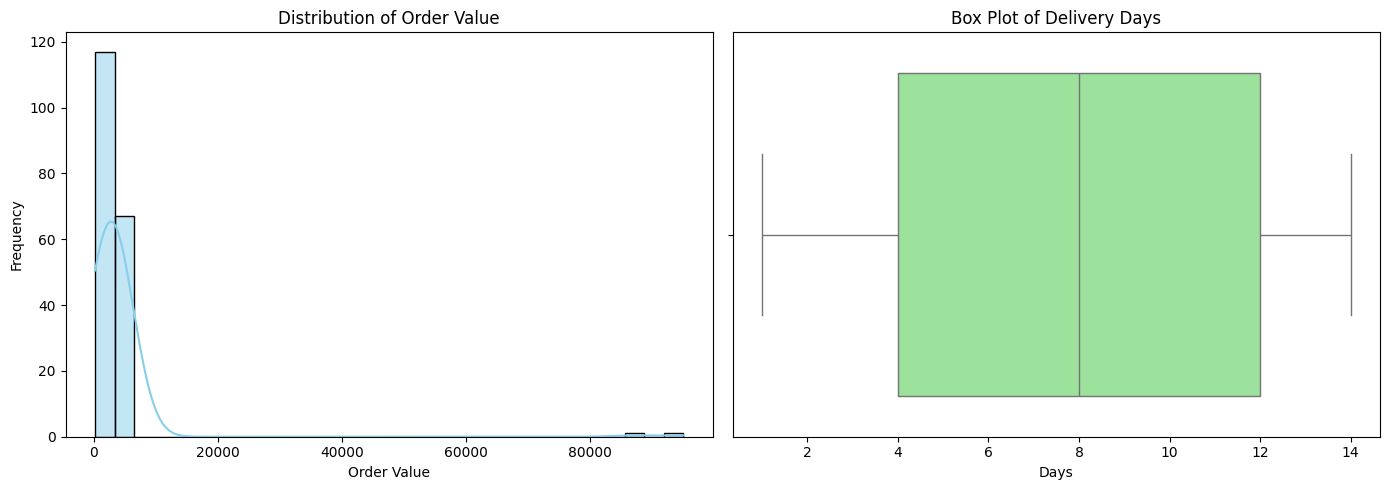

In [10]:
#Task 2 — Summarize & Visualize

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Summary of all numerical columns
summary = df.describe()
print("1. Summary of all numerical columns:\n",summary)

# Two observations from summary
print("\n Two observations from summary:")
print("\n1. Order_Value column shows a huge disparity exists between the 75th percentile ($3,800$) and the peak value ($95,000). Including these figures will result in skewed 'average' sales data.")
print("\n2. The delivery_days mean and median (50%) are likely very close (around 7-8 days), suggesting a relatively uniform distribution of delivery times across the dataset.")

# Histogram for order_value column to visualize distribution
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['order_value'].dropna(), bins=30, kde=True, color='skyblue')
plt.title('Distribution of Order Value')
plt.xlabel('Order Value')
plt.ylabel('Frequency')

# Box plot for delivery_days to inspect for outliers
plt.subplot(1, 2, 2)
sns.boxplot(x=df['delivery_days'], color='lightgreen')
plt.title('Box Plot of Delivery Days')
plt.xlabel('Days')

plt.tight_layout()
plt.show()

# Task 3 — Correlation Analysis

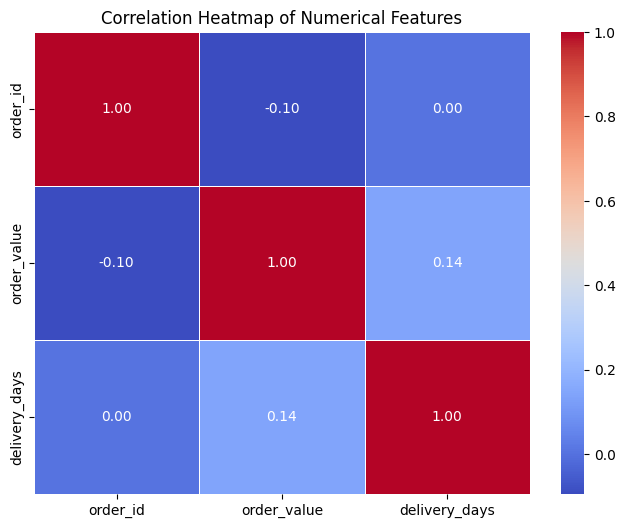

In [11]:
# Task 3 — Correlation Analysis

# Compute the Correlation Matrix for all numerical columns
corr_matrix = df.select_dtypes(include=[np.number]).corr()

# Plot Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

# Observation from the Heatmap:

Heatmap shows  very low correlation between order_value and delivery_days. It means that the price of an item doesn't significantly impact how long it takes to be delivered in this specific dataset.